In [21]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt

from sklearn.preprocessing import MinMaxScaler
from sklearn.metrics import mean_absolute_error, mean_squared_error, r2_score

from tensorflow.keras.models import Sequential
from tensorflow.keras.layers import Input, LSTM, Dense, Dropout
from tensorflow.keras.callbacks import EarlyStopping

In [22]:
data = pd.read_csv("../data/processed/final_sensor_assisted_dataset.csv")

print(data.shape)
data.head()

(11010, 42)


,farmer_id,weather_condition,collection_shift,pH,pH_duplicate,turbidity_ntu,turbidity_log,temperature_c_x,ammonia_content,color_score,...,temp_min,temp_mean,humidity_max,humidity_min,precipitation,wind_speed,storage_risk,tapping_total_hour,weather_stress,vfa
0,0.652174,0.666667,1.0,0.465690,0.465541,0.086036,0.337074,0.377073,0.219000,1.00,...,0.492275,0.507725,0.507725,0.492275,0.492275,0.492275,0.0,0.449019,0.377120,0.073
1,0.673913,0.000000,1.0,0.479828,0.480012,0.069748,0.273708,0.397927,0.234667,0.75,...,0.492275,0.507725,0.507725,0.492275,0.492275,0.492275,0.0,0.449019,0.397972,0.061
2,0.652174,1.000000,1.0,0.532500,0.532451,0.053599,0.190202,0.391341,0.243000,0.50,...,0.492275,0.507725,0.507725,0.492275,0.492275,0.492275,0.0,0.449019,0.391387,0.036
3,0.586957,0.333333,1.0,0.427845,0.428358,0.098205,0.375919,0.392561,0.207333,1.00,...,0.492275,0.507725,0.507725,0.492275,0.492275,0.492275,0.0,0.449019,0.392607,0.094
4,0.369565,1.000000,1.0,0.465862,0.465722,0.082577,0.324852,0.369756,0.223667,1.00,...,0.000000,1.000000,1.000000,0.000000,0.000000,0.000000,0.0,0.027221,0.371999,0.071


In [23]:
X = data.drop(columns=['vfa'])
y = data['vfa']

print(X.shape)
print(y.shape)

(11010, 41)
(11010,)


In [24]:
scaler_X = MinMaxScaler()
X_scaled = scaler_X.fit_transform(X)

scaler_y = MinMaxScaler()
y_scaled = scaler_y.fit_transform(y.values.reshape(-1, 1))

In [30]:
def create_sequences(X, y, time_steps=3):
    Xs, ys = [], []

    for i in range(len(X) - time_steps):
        Xs.append(X[i:i + time_steps])
        ys.append(y[i + time_steps])

    return np.array(Xs), np.array(ys)


TIME_STEPS = 3

X_seq, y_seq = create_sequences(
    X_scaled,
    y_scaled,
    TIME_STEPS
)

print(X_seq.shape)
print(y_seq.shape)

(11007, 3, 41)
(11007, 1)


In [31]:
split_index = int(len(X_seq) * 0.8)

X_train = X_seq[:split_index]
X_test = X_seq[split_index:]

y_train = y_seq[:split_index]
y_test = y_seq[split_index:]

print(X_train.shape)
print(X_test.shape)

(8805, 3, 41)
(2202, 3, 41)


In [32]:
model = Sequential([
    Input(shape=(X_train.shape[1], X_train.shape[2])),

    LSTM(128, return_sequences=True),
    Dropout(0.2),

    LSTM(64),
    Dropout(0.2),

    Dense(64, activation='relu'),
    Dense(32, activation='relu'),
    Dense(1)
])

model.compile(
    optimizer='adam',
    loss='mse'
)

model.summary()

Model: "sequential_3"

┏━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━┓
┃ Layer (type)                ┃ Output Shape        ┃     Param # ┃
┡━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━┩
│ lstm_5 (LSTM)               │ (None, 3, 128)      │      87,040 │
├─────────────────────────────┼─────────────────────┼─────────────┤
│ dropout_5 (Dropout)         │ (None, 3, 128)      │           0 │
├─────────────────────────────┼─────────────────────┼─────────────┤
│ lstm_6 (LSTM)               │ (None, 64)          │      49,408 │
├─────────────────────────────┼─────────────────────┼─────────────┤
│ dropout_6 (Dropout)         │ (None, 64)          │           0 │
├─────────────────────────────┼─────────────────────┼─────────────┤
│ dense_9 (Dense)             │ (None, 64)          │       4,160 │
├─────────────────────────────┼─────────────────────┼─────────────┤
│ dense_10 (Dense)            │ (None, 32)          │       2,080 │
├─────────────────────────────┼─────────────────────┼─────────────┤
│ dense_11 (Dense)            │ (None, 1)           │          33 │
└─────────────────────────────┴─────────────────────┴─────────────┘

 Total params: 142,721 (557.50 KB)

 Trainable params: 142,721 (557.50 KB)

 Non-trainable params: 0 (0.00 B)

In [33]:
early_stop = EarlyStopping(
    monitor='val_loss',
    patience=10,
    restore_best_weights=True
)

history = model.fit(
    X_train,
    y_train,
    epochs=100,
    batch_size=32,
    validation_split=0.2,
    callbacks=[early_stop],
    verbose=1
)

Epoch 1/100
221/221 ━━━━━━━━━━━━━━━━━━━━ 7s 14ms/step - loss: 0.1009 - val_loss: 0.0940
Epoch 2/100
221/221 ━━━━━━━━━━━━━━━━━━━━ 3s 11ms/step - loss: 0.0942 - val_loss: 0.0922
Epoch 3/100
221/221 ━━━━━━━━━━━━━━━━━━━━ 3s 13ms/step - loss: 0.0931 - val_loss: 0.0977
Epoch 4/100
221/221 ━━━━━━━━━━━━━━━━━━━━ 3s 12ms/step - loss: 0.0935 - val_loss: 0.0956
Epoch 5/100
221/221 ━━━━━━━━━━━━━━━━━━━━ 2s 11ms/step - loss: 0.0925 - val_loss: 0.0927
Epoch 6/100
221/221 ━━━━━━━━━━━━━━━━━━━━ 3s 11ms/step - loss: 0.0921 - val_loss: 0.0926
Epoch 7/100
221/221 ━━━━━━━━━━━━━━━━━━━━ 3s 11ms/step - loss: 0.0923 - val_loss: 0.0933
Epoch 8/100
221/221 ━━━━━━━━━━━━━━━━━━━━ 3s 11ms/step - loss: 0.0921 - val_loss: 0.0932
Epoch 9/100
221/221 ━━━━━━━━━━━━━━━━━━━━ 3s 11ms/step - loss: 0.0920 - val_loss: 0.0932
Epoch 10/100
221/221 ━━━━━━━━━━━━━━━━━━━━ 3s 11ms/step - loss: 0.0920 - val_loss: 0.0922
Epoch 11/100
221/221 ━━━━━━━━━━━━━━━━━━━━ 2s 11ms/step - loss: 0.0922 - val_loss: 0.0922
Epoch 12/100
221/221 ━━━━━━━━━

In [34]:
y_pred_scaled = model.predict(X_test)

y_pred = scaler_y.inverse_transform(y_pred_scaled)
y_true = scaler_y.inverse_transform(y_test)

mae = mean_absolute_error(y_true, y_pred)
rmse = np.sqrt(mean_squared_error(y_true, y_pred))
r2 = r2_score(y_true, y_pred)

print("LSTM MAE:", mae)
print("LSTM RMSE:", rmse)
print("LSTM R2 Score:", r2)

69/69 ━━━━━━━━━━━━━━━━━━━━ 1s 9ms/step
LSTM MAE: 0.02008521635808748
LSTM RMSE: 0.022860645644839032
LSTM R2 Score: -0.00033739447872060957


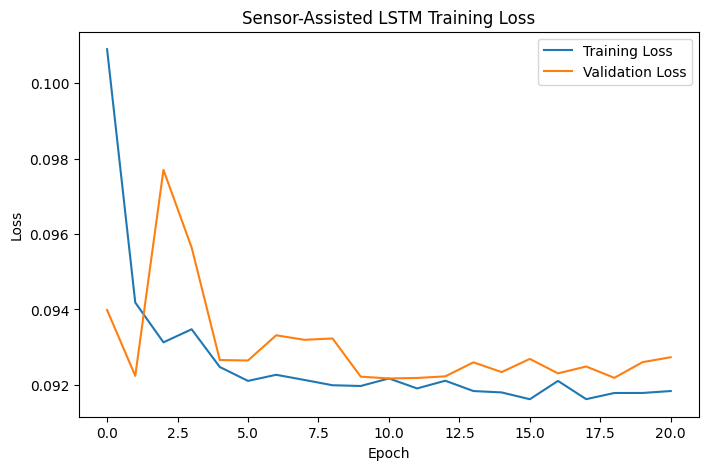

In [35]:
plt.figure(figsize=(8,5))
plt.plot(history.history['loss'], label='Training Loss')
plt.plot(history.history['val_loss'], label='Validation Loss')
plt.xlabel("Epoch")
plt.ylabel("Loss")
plt.title("Sensor-Assisted LSTM Training Loss")
plt.legend()
plt.show()

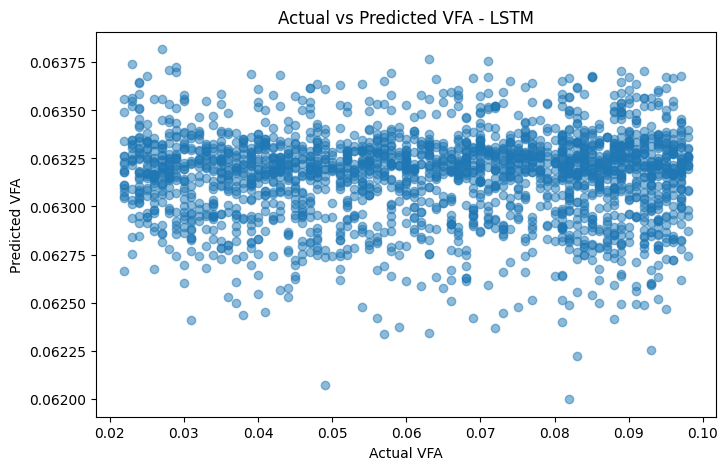

In [36]:
plt.figure(figsize=(8,5))
plt.scatter(y_true, y_pred, alpha=0.5)
plt.xlabel("Actual VFA")
plt.ylabel("Predicted VFA")
plt.title("Actual vs Predicted VFA - LSTM")
plt.show()